In [ ]:
%pip install -q torch pandas matplotlib tqdm scikit-learn


In [ ]:
import math
import random
import re
import pickle
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


Устройство: cuda
GPU: Tesla T4


In [ ]:
CORPUS_MODE = 'csv'
CSV_PATH = '/content/ru_myv_parallel.csv'
CSV_SEPARATOR = 'auto'
SRC_COLUMN = 'ru'
TGT_COLUMN = 'myv'

SRC_TXT_PATH = '/content/ru.txt'
TGT_TXT_PATH = '/content/myv.txt'

MIN_SENTENCE_CHARS = 1
MAX_TOKENS_PER_SENTENCE = 80


In [ ]:
def demo_corpus():
    pairs = [
      ('я дома', 'мон кудосо'),
      ('ты дома', 'тон кудосо'),
      ('он дома', 'сон кудосо'),
      ('мы дома', 'минь кудосо'),
      ('они дома', 'содамо кудосо'),

      ('я в городе', 'мон ошсо'),
      ('ты в городе', 'тон ошсо'),
      ('мы в деревне', 'минь велесэ'),

      ('я работаю', 'мон аштямс'),
      ('ты работаешь', 'тон аштят'),
      ('он работает', 'сон аштя'),
      ('мы работаем', 'минь аштятано'),
      ('они работают', 'содамо аштят'),

      ('я читаю', 'мон ловнан'),
      ('ты читаешь', 'тон ловнат'),
      ('мы читаем', 'минь ловнатано'),
      ('они читают', 'содамо ловнат'),

      ('я пишу', 'мон сёрмадтан'),
      ('ты пишешь', 'тон сёрмадтат'),
      ('он пишет', 'сон сёрмадта'),
      ('мы пишем', 'минь сёрмадтатано'),

      ('я говорю', 'мон кортамс'),
      ('ты говоришь', 'тон кортат'),
      ('он говорит', 'сон корта'),
      ('мы говорим', 'минь кортатано'),

      ('я понимаю', 'мон панжамс'),
      ('ты понимаешь', 'тон панжат'),
      ('он понимает', 'сон панжа'),
      ('мы понимаем', 'минь панжатано'),

      ('я учу эрзянский язык', 'мон тонавтнян эрзянь кель'),
      ('ты учишь русский язык', 'тон тонавт тонь рузонь кель'),
      ('он учит слова', 'сон тонавты валхт'),

      ('я люблю читать', 'мон вечкан ловномс'),
      ('я люблю писать', 'мон вечкан сёрмадтомс'),
      ('я люблю учиться', 'мон вечкан тонавтнемс'),

      ('я хочу есть', 'мон конам ашамс'),
      ('я хочу пить', 'мон конам вадямс'),
      ('я хочу спать', 'мон конам пельнемс'),

      ('я устал', 'мон арсемс'),
      ('я рад', 'мон радо'),
      ('мне холодно', 'монь кудо'),
      ('мне жарко', 'монь пелькс'),

      ('это правильно', 'те паро'),
      ('это неправильно', 'те апаро'),
      ('это интересно', 'те интереснэ'),
      ('это сложно', 'те васня'),

      ('я знаю', 'мон мэдян'),
      ('я не знаю', 'мон а мэдян'),
      ('я помню', 'мон помнян'),
      ('я забыл', 'мон кандсын'),

      ('где ты живёшь', 'кода тон эрит'),
      ('где он работает', 'кода сон аштя'),
      ('куда ты идёшь', 'кода тон молят'),
      ('откуда ты', 'кода тонь лиссь'),

      ('мне нравится эта книга', 'монь лембе те книга'),
      ('мне нравится этот дом', 'монь лембе те кудо'),
      ('мне нравится этот язык', 'монь лембе те кель'),

      ('я хочу купить книгу', 'мон конам кувалемс книга'),
      ('я хочу продать машину', 'мон конам аштемс машина'),
      ('я хочу посмотреть фильм', 'мон конам ваномс фильм'),

      ('я изучаю машинный перевод', 'мон тонавтнян машинань ютавтома'),
      ('модель обучается', 'модель тонавтни'),
      ('данные загружаются', 'датат таргадт'),
      ('данные обрабатываются', 'датат лиссьт'),
      ('модель делает ошибку', 'модель ливтямс ливтема'),
      ('ошибка исправлена', 'ливтема тевс паро'),
      ('модель улучшилась', 'модель парстась'),
      ('модель ухудшилась', 'модель апарстась'),

      ('корпус маленький', 'корпус аламо'),
      ('корпус большой', 'корпус покш'),
      ('корпус плохой', 'корпус апаро'),
      ('корпус хороший', 'корпус паро'),

      ('добавьте больше данных', 'поладо седе ламо датат'),
      ('добавьте больше примеров', 'поладо седе ламо примеранть'),
      ('проверьте качество', 'ванодо качествонь'),
      ('улучшите модель', 'парсто модельсэнть'),
      ('обучите модель', 'тонавтне модельсэнть'),
      ('перезапустите обучение', 'одови таргадо тонавтома'),

      ('перевод плохой', 'ютавтомась апаро'),
      ('перевод хороший', 'ютавтомась паро'),
      ('перевод неполный', 'ютавтомась аполадо'),
      ('перевод точный', 'ютавтомась точнэ'),

      ('я создаю корпус', 'мон ливтян корпус'),
      ('мы собираем данные', 'минь ливтятано датат'),
      ('мы размечаем текст', 'минь метятано текст'),
      ('разметка готова', 'метема анок'),

      ('модель использует внимание', 'модель тевс ваномань механизм'),
      ('внимание улучшает перевод', 'ваномась парсто ютавтоманть'),
      ('трансформер обучается долго', 'трансформер тонавтни васол'),
      ('трансформер требует данных', 'трансформер датат кона'),
  ]

    return pd.DataFrame(pairs, columns=['ru', 'myv'])


def read_parallel_csv(path, separator, src_column, tgt_column):
    if separator == 'auto':
        frame = pd.read_csv(path, sep=None, engine='python')
    else:
        frame = pd.read_csv(path, sep=separator)
    if src_column not in frame.columns or tgt_column not in frame.columns:
        raise ValueError(f'В файле должны быть колонки {src_column!r} и {tgt_column!r}. Найдены: {list(frame.columns)}')
    return frame[[src_column, tgt_column]].rename(columns={src_column: 'ru', tgt_column: 'myv'})


def read_parallel_txt(src_path, tgt_path):
    src_lines = Path(src_path).read_text(encoding='utf-8').splitlines()
    tgt_lines = Path(tgt_path).read_text(encoding='utf-8').splitlines()
    if len(src_lines) != len(tgt_lines):
        raise ValueError(f'Количество строк не совпадает: {len(src_lines)} и {len(tgt_lines)}')
    return pd.DataFrame({'ru': src_lines, 'myv': tgt_lines})


def load_corpus():
    if CORPUS_MODE == 'csv' and Path(CSV_PATH).exists():
        return read_parallel_csv(CSV_PATH, CSV_SEPARATOR, SRC_COLUMN, TGT_COLUMN), 'csv'
    if CORPUS_MODE == 'txt_pair' and Path(SRC_TXT_PATH).exists() and Path(TGT_TXT_PATH).exists():
        return read_parallel_txt(SRC_TXT_PATH, TGT_TXT_PATH), 'txt_pair'
    return demo_corpus(), 'demo'

raw_df, corpus_source = load_corpus()
print('Источник корпуса:', corpus_source)
print('Размер до очистки:', len(raw_df))
raw_df.head()


Источник корпуса: demo
Размер до очистки: 90


,ru,myv
0,я дома,мон кудосо
1,ты дома,тон кудосо
2,он дома,сон кудосо
3,мы дома,минь кудосо
4,они дома,содамо кудосо


In [ ]:
TOKEN_RE = re.compile(r"[\wёЁӥӦӧӱӰӓӒ]+|[^\w\s]", re.UNICODE)


def normalize_text(text):
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)
    return text


def tokenize(text):
    return TOKEN_RE.findall(text.lower())


def clean_corpus(frame):
    cleaned = frame.copy()
    cleaned['ru'] = cleaned['ru'].map(normalize_text)
    cleaned['myv'] = cleaned['myv'].map(normalize_text)
    cleaned = cleaned[(cleaned['ru'].str.len() >= MIN_SENTENCE_CHARS) & (cleaned['myv'].str.len() >= MIN_SENTENCE_CHARS)]
    cleaned = cleaned.drop_duplicates(subset=['ru', 'myv'])
    cleaned['ru_tokens'] = cleaned['ru'].map(lambda x: len(tokenize(x)))
    cleaned['myv_tokens'] = cleaned['myv'].map(lambda x: len(tokenize(x)))
    cleaned = cleaned[(cleaned['ru_tokens'] <= MAX_TOKENS_PER_SENTENCE) & (cleaned['myv_tokens'] <= MAX_TOKENS_PER_SENTENCE)]
    return cleaned[['ru', 'myv']].reset_index(drop=True)

df = clean_corpus(raw_df)
print('Размер после очистки:', len(df))
df.sample(min(5, len(df)), random_state=SEED)


Размер после очистки: 90


,ru,myv
40,мне холодно,монь кудо
22,ты говоришь,тон кортат
55,мне нравится этот дом,монь лембе те кудо
70,корпус плохой,корпус апаро
0,я дома,мон кудосо


In [ ]:
SPECIALS = ['<pad>', '<bos>', '<eos>', '<unk>']
PAD, BOS, EOS, UNK = range(4)

@dataclass
class Vocab:
    stoi: dict
    itos: list

    def encode(self, tokens):
        return [self.stoi.get(tok, UNK) for tok in tokens]

    def decode(self, ids):
        tokens = []
        for idx in ids:
            if idx in (PAD, BOS, EOS):
                continue
            tokens.append(self.itos[idx] if idx < len(self.itos) else '<unk>')
        text = ' '.join(tokens)
        text = text.replace(' .', '.').replace(' ,', ',').replace(' !', '!').replace(' ?', '?').replace(' :', ':').replace(' ;', ';')
        return text


def build_vocab(texts, min_freq=1):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    tokens = [tok for tok, freq in counter.most_common() if freq >= min_freq and tok not in SPECIALS]
    itos = SPECIALS + tokens
    stoi = {tok: idx for idx, tok in enumerate(itos)}
    return Vocab(stoi=stoi, itos=itos)

src_vocab = build_vocab(df['ru'])
tgt_vocab = build_vocab(df['myv'])

print('Размер русского словаря:', len(src_vocab.itos))
print('Размер эрзянского словаря:', len(tgt_vocab.itos))
print('Примеры русских токенов:', src_vocab.itos[:20])
print('Примеры эрзянских токенов:', tgt_vocab.itos[:20])


Размер русского словаря: 122
Размер эрзянского словаря: 115
Примеры русских токенов: ['<pad>', '<bos>', '<eos>', '<unk>', 'я', 'ты', 'мы', 'он', 'модель', 'хочу', 'перевод', 'дома', 'мне', 'корпус', 'это', 'они', 'в', 'язык', 'люблю', 'нравится']
Примеры эрзянских токенов: ['<pad>', '<bos>', '<eos>', '<unk>', 'мон', 'тон', 'минь', 'сон', 'те', 'конам', 'кудосо', 'монь', 'модель', 'датат', 'корпус', 'паро', 'кода', 'ютавтомась', 'содамо', 'кель']


In [ ]:
if len(df) < 10:
    raise ValueError('Для обучения нужно хотя бы 10 пар предложений. Лучше использовать сотни или тысячи пар.')

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

class TranslationDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        src = [BOS] + src_vocab.encode(tokenize(row['ru'])) + [EOS]
        tgt = [BOS] + tgt_vocab.encode(tokenize(row['myv'])) + [EOS]
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)


def collate_batch(batch):
    src_batch, tgt_batch = zip(*batch)
    src = nn.utils.rnn.pad_sequence(src_batch, padding_value=PAD, batch_first=True)
    tgt = nn.utils.rnn.pad_sequence(tgt_batch, padding_value=PAD, batch_first=True)
    return src, tgt

BATCH_SIZE = 32
train_loader = DataLoader(TranslationDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
valid_loader = DataLoader(TranslationDataset(valid_df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_dataset = TranslationDataset(test_df)

print('Train:', len(train_df))
print('Valid:', len(valid_df))
print('Test:', len(test_df))


Train: 72
Valid: 9
Test: 9


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=128, nhead=4, num_encoder_layers=3, num_decoder_layers=3, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD)
        self.positional_encoding = PositionalEncoding(d_model, dropout=dropout)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.generator = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt_input):
        src_key_padding_mask = src.eq(PAD)
        tgt_key_padding_mask = tgt_input.eq(PAD)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_input.size(1), device=tgt_input.device)
        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt_input) * math.sqrt(self.d_model))
        output = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )
        return self.generator(output)

model = Seq2SeqTransformer(len(src_vocab.itos), len(tgt_vocab.itos)).to(DEVICE)
print('Количество параметров:', sum(p.numel() for p in model.parameters()))


Количество параметров: 1039475


In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    total_tokens = 0
    for src, tgt in loader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]
        with torch.set_grad_enabled(train):
            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        tokens = tgt_output.ne(PAD).sum().item()
        total_loss += loss.item() * tokens
        total_tokens += tokens
    return total_loss / max(total_tokens, 1)

EPOCHS = 40
history = []
for epoch in tqdm(range(1, EPOCHS + 1)):
    train_loss = run_epoch(train_loader, train=True)
    valid_loss = run_epoch(valid_loader, train=False)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'valid_loss': valid_loss})
    if epoch == 1 or epoch % 5 == 0:
        print(f'epoch={epoch:03d} train_loss={train_loss:.4f} valid_loss={valid_loss:.4f}')


  0%|          | 0/40 [00:00<?, ?it/s]

epoch=001 train_loss=4.7179 valid_loss=4.0047


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


epoch=005 train_loss=3.5811 valid_loss=3.6487
epoch=010 train_loss=3.0034 valid_loss=3.2916
epoch=015 train_loss=2.6193 valid_loss=3.0241
epoch=020 train_loss=2.2692 valid_loss=2.8418
epoch=025 train_loss=1.9871 valid_loss=2.6755
epoch=030 train_loss=1.7198 valid_loss=2.5562
epoch=035 train_loss=1.4690 valid_loss=2.4374
epoch=040 train_loss=1.3289 valid_loss=2.3390


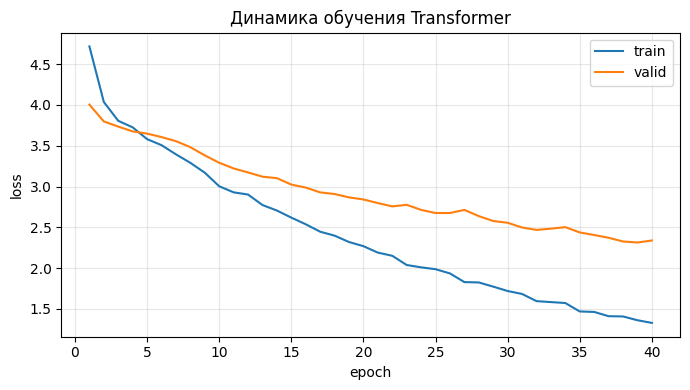

In [ ]:
history_df = pd.DataFrame(history)
plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], label='train')
plt.plot(history_df['epoch'], history_df['valid_loss'], label='valid')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Динамика обучения Transformer')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
@torch.no_grad()
def translate(sentence, max_len=80):
    model.eval()
    src_ids = [BOS] + src_vocab.encode(tokenize(sentence)) + [EOS]
    src = torch.tensor(src_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
    generated = torch.tensor([[BOS]], dtype=torch.long, device=DEVICE)
    for _ in range(max_len):
        logits = model(src, generated)
        next_id = logits[:, -1].argmax(dim=-1).item()
        generated = torch.cat([generated, torch.tensor([[next_id]], dtype=torch.long, device=DEVICE)], dim=1)
        if next_id == EOS:
            break
    return tgt_vocab.decode(generated.squeeze(0).tolist())

sample_sentences = test_df['ru'].head(10).tolist()
translations = [{'ru': sent, 'prediction_myv': translate(sent)} for sent in sample_sentences]
pd.DataFrame(translations)


,ru,prediction_myv
0,мне холодно,монь пелькс
1,ты говоришь,тон кудосо
2,он работает,сон сёрмадта
3,ты понимаешь,тон аштят
4,корпус плохой,корпус покш
5,модель использует внимание,модель апарстась
6,ты пишешь,тон кудосо
7,они дома,тон кудосо
8,я хочу есть,мон конам пельнемс


In [ ]:
def token_overlap(prediction, reference):
    pred_tokens = tokenize(prediction)
    ref_tokens = tokenize(reference)
    if not ref_tokens:
        return 0.0
    pred_counter = Counter(pred_tokens)
    ref_counter = Counter(ref_tokens)
    overlap = sum(min(pred_counter[token], ref_counter[token]) for token in ref_counter)
    return overlap / len(ref_tokens)

rows = []
for _, row in test_df.iterrows():
    prediction = translate(row['ru'])
    rows.append({
        'ru': row['ru'],
        'reference_myv': row['myv'],
        'prediction_myv': prediction,
        'exact_match': int(prediction == row['myv'].lower()),
        'token_overlap': token_overlap(prediction, row['myv']),
    })

results_df = pd.DataFrame(rows)
results_df.head(20)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


,ru,reference_myv,prediction_myv,exact_match,token_overlap
0,мне холодно,монь кудо,монь пелькс,0,0.500000
1,ты говоришь,тон кортат,тон кудосо,0,0.500000
2,он работает,сон аштя,сон сёрмадта,0,0.500000
3,ты понимаешь,тон панжат,тон аштят,0,0.500000
4,корпус плохой,корпус апаро,корпус покш,0,0.500000
5,модель использует внимание,модель тевс ваномань механизм,модель апарстась,0,0.250000
6,ты пишешь,тон сёрмадтат,тон кудосо,0,0.500000
7,они дома,содамо кудосо,тон кудосо,0,0.500000
8,я хочу есть,мон конам ашамс,мон конам пельнемс,0,0.666667


In [ ]:
metrics = pd.DataFrame([{
    'exact_match': results_df['exact_match'].mean(),
    'mean_token_overlap': results_df['token_overlap'].mean(),
    'test_size': len(results_df),
}])
metrics


,exact_match,mean_token_overlap,test_size
0,0.0,0.490741,9


In [ ]:
checkpoint_path = 'ru_myv_transformer.pt'
vocab_path = 'ru_myv_vocab.pkl'

checkpoint = {
    'model_state_dict': model.state_dict(),
    'src_vocab_size': len(src_vocab.itos),
    'tgt_vocab_size': len(tgt_vocab.itos),
    'd_model': model.d_model,
}
torch.save(checkpoint, checkpoint_path)

with open(vocab_path, 'wb') as file:
    pickle.dump({'src_vocab': src_vocab, 'tgt_vocab': tgt_vocab}, file)

print('Сохранена модель:', checkpoint_path)
print('Сохранены словари:', vocab_path)


Сохранена модель: ru_myv_transformer.pt
Сохранены словари: ru_myv_vocab.pkl
